# Tutorial 14.5: Exit-wave evolution through a layered sample

This notebook is derived from Tutorial 14.4, but stops at the sample exit wave. There is no Au holographic mask, no object or reference holes, no detector, no FTH reconstruction, and no sample-to-detector Fraunhofer/FFT propagation. Free-space propagation between sample slices is retained.

The workflow is: define the real-space grid and illumination → define the sample and its chemical/magnetic texture → apply each material slice → inspect the complex wave after selected depths. The recorded field after slice `i` is therefore the exit wave of the partial sample comprising slices `0..i`.

In [14]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

from scipy.ndimage import distance_transform_edt
from scattering_calculator.database.database_loading import material_params
from scattering_calculator.experimental_conditions import light_beam
from scattering_calculator.sample_generator import pattern_generator
from scattering_calculator.sample_generator.pattern_generator import _estimate_labyrinth_stripe_width_fft
from scattering_calculator.simulation_pipelines import simulation_configuration as sim

plt.rcParams["figure.constrained_layout.use"] = True

## 1. User controls: grid, X-rays, and illumination

The sample-plane grid is specified directly because there is no detector geometry in this experiment. Increase `grid_shape` or decrease `real_space_pixel_size` to resolve finer sample structure; memory scales with the number of pixels and sample slices.

In [15]:
# ########################################
# REAL-SPACE GRID
# ########################################
grid_shape = (256,256)                # (Ny, Nx)
real_space_pixel_size = 1.5e-9         # m; 1.5 nm gives 8 pixels per 12 nm period
sample_shape = [0, *grid_shape]

# ########################################
# X-RAY SOURCE AND ILLUMINATION
# ########################################
xray_energy = 778.0                    # eV
photon_flux = 5e8                      # photons / second
polarization = "CR"                  # e.g. "CR", "CL", "LH", or "LV"
transverse_coherence_length = (100e-6, 100e-6)  # retained source metadata

illumination_function = "gaussian"   # "gaussian" or "plane_wave"
illumination_center = np.array([0.0, 0.0])  # m, (y, x)
illumination_focus_distance = 0.0       # m from beam waist
illumination_fwhm = 50e-6               # m at beam waist; 100x larger than 500 nm
illumination_alpha_beam = (0.0, 0.0)    # rad, (alpha_y, alpha_x)

xray = sim.XRayConfig(
    energy=xray_energy, photon_flux=photon_flux, pol=polarization,
    coherence_length=transverse_coherence_length,
)
xray.setup()

fov_nm = np.asarray(grid_shape) * real_space_pixel_size * 1e9
print(f"grid: {grid_shape}, pixel: {real_space_pixel_size*1e9:.2f} nm, FOV: {fov_nm} nm")

grid: (256, 256), pixel: 1.50 nm, FOV: [384. 384.] nm


## 2. User controls: sample properties

As in Tutorial 14.4, the nominal Co/Dy multilayer is represented as coarse depth slices of a 126 nm CoDy region. Its local Co fraction follows the same columnar nucleation-and-growth model. The physical sample contains only the film stack below—there is deliberately no holographic mask or reference-hole geometry.

In [51]:
# ########################################
# FILM STACK
# ########################################
CO_NOMINAL_NM, DY_NOMINAL_NM = 0.75, 0.30
N_REPEATS = 2000
CODY_TOTAL_NM = N_REPEATS * (CO_NOMINAL_NM + DY_NOMINAL_NM)
N_SUB = 80                            # finer sampling in depth
SUB_THICKNESS_NM = CODY_TOTAL_NM / N_SUB
f_background = CO_NOMINAL_NM / (CO_NOMINAL_NM + DY_NOMINAL_NM)

# Beam-first order. Edit this recipe and the texture controls below to define the sample.
sample_recipe = f"Ta(4)/Pt(6)/[Co({SUB_THICKNESS_NM})]x{N_SUB}/Ta(3)/Pt(4)"

# Chemical texture
target_period = 12e-9                 # m
chemical_depth_profile = "uniform"    # "cones" or "uniform" (same domains in every slice)
chemical_start_layer = 3
chemical_growth_layers = 3           # approximate number of slices needed to reach a wall
chemical_richness = 1.0               # 0 = uniform alloy, 1 = full Co/Dy contrast
chemical_seed = 11

# Magnetic texture
magnetic_stripe_width = 300e-9
magnetic_seed = 7

sample = sim.SampleConfig(
    recipe=sample_recipe, sample_shape=sample_shape,
    real_space_pixel_size=real_space_pixel_size, xray_config=xray,
    sample_name="layer-resolved chemical columnar sample",
)
sample.setup()
layer_names = list(sample.sample_structure.layer_names)
layer_thicknesses = np.asarray(sample.sample_structure.layer_thicknesses, dtype=float)
chem_indices = [i for i, name in enumerate(layer_names) if name == "Co"]

# Structure uses the same mask field for ordinary sample support and FTH
# apertures. With no holographic mask it remains None, so explicitly assign
# an all-open support: every pixel contains the material of its layer.
sample_support = np.ones((len(layer_names), *grid_shape), dtype=float)
sample.assign_aperture_mask(sample_support)
print("recipe:", sample_recipe)
print("layers:", layer_names)
print(f"total thickness: {layer_thicknesses.sum()*1e9:.1f} nm; CoDy slices: {len(chem_indices)}")

recipe: Ta(4)/Pt(6)/[Co(26.25)]x80/Ta(3)/Pt(4)
layers: ['Ta', 'Pt', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Co', 'Ta', 'Pt']
total thickness: 2117.0 nm; CoDy slices: 80


## 3. Build the depth-dependent chemical and magnetic sample

The chemical-domain builder is kept from Tutorial 14.4. Each Co placeholder slice is subsequently replaced by the local Co/Dy-mixed dielectric response while preserving its magnetic tensor contribution.

In [52]:
def build_columnar_domains(base_pattern_2d, n_sub, start_layer, widen_rate_px_per_layer,
                            richness, f_background, max_radius_px):
    """Return a (n_sub, Ny, Nx) local Co-fraction field in [0, 1]."""
    binary = base_pattern_2d > 0
    dist_pos = distance_transform_edt(binary)
    dist_neg = distance_transform_edt(~binary)
    dist_to_wall = np.where(binary, dist_pos, dist_neg)
    pure = np.where(binary, 1.0, 0.0)

    f_stack = np.zeros((n_sub, *base_pattern_2d.shape))
    for z in range(n_sub):
        grown_radius = np.clip(widen_rate_px_per_layer * (z - start_layer), 0, max_radius_px)
        occupied = (max_radius_px - dist_to_wall) <= grown_radius
        raw = np.where(occupied, pure, f_background)
        f_stack[z] = f_background + richness * (raw - f_background)
    return f_stack


stripe_width_px = (target_period / 2) / real_space_pixel_size
if stripe_width_px < 2:
    print("WARNING: fewer than four pixels per chemical period; reduce real_space_pixel_size.")

seed_pattern, seed_meta = pattern_generator.create_binary_labyrinth_pattern(
    sz_array=list(grid_shape), stripe_width=stripe_width_px, sigma=0.5,
    H=64, W=64, n_steps=60, region="custom", use_gpu=False, seed=chemical_seed,
    k0=1.05, eps=0.8, target_mean=0.0, noise_amp=0.0,
    max_hole_area=4, saturation_fraction_threshold=0.01,
    max_auto_size=max(4096, 2 * max(grid_shape)),
    max_auto_pixels=max(4096, 2 * max(grid_shape)) ** 2,
)
_, measured_period_px = _estimate_labyrinth_stripe_width_fft(seed_pattern)
print(f"measured chemical period: {measured_period_px*real_space_pixel_size*1e9:.2f} nm")

if chemical_depth_profile == "cones":
    f_stack = build_columnar_domains(
        seed_pattern, N_SUB, start_layer=chemical_start_layer,
        widen_rate_px_per_layer=stripe_width_px / chemical_growth_layers,
        richness=chemical_richness, f_background=f_background,
        max_radius_px=stripe_width_px,
    )
elif chemical_depth_profile == "uniform":
    # Repeat exactly the same Co/Dy map through the complete CoDy thickness.
    pure_2d = np.where(seed_pattern > 0, 1.0, 0.0)
    composition_2d = f_background + chemical_richness * (pure_2d - f_background)
    f_stack = np.repeat(composition_2d[None, ...], N_SUB, axis=0)
else:
    raise ValueError(
        f"Unknown chemical_depth_profile={chemical_depth_profile!r}; "
        "choose 'cones' or 'uniform'."
    )
print(f"chemical depth profile: {chemical_depth_profile}")

measured chemical period: 13.30 nm
chemical depth profile: uniform


In [53]:
magnetic = sim.MagneticPatternConfig(
    pattern_type_method="binary_labyrinth_pattern",
    shape=grid_shape, real_space_pixel_size=real_space_pixel_size,
    pattern_config={
        "stripe_width": magnetic_stripe_width, "sigma": 5e-9,
        "H": 128, "W": 128, "n_steps": 60, "region": "custom",
        "use_gpu": False, "seed": magnetic_seed, "k0": 1.05, "eps": 0.8,
        "target_mean": 0.0, "noise_amp": 0.0, "quadratic_coefficient": 0.0,
        "max_hole_area": 9, "saturation_fraction_threshold": 0.01,
    },
)
magnetic.create_pattern()
mz = magnetic.magnetic_pattern
magnetization = pattern_generator.map_magnetization_to_3d(
    magnetic_pattern_x=np.zeros_like(mz),
    magnetic_pattern_y=np.sqrt(np.clip(1.0 - mz**2, 0.0, 1.0)),
    magnetic_pattern_z=mz, nr_repeats=len(layer_names),
)
sample.assign_magnetic_pattern(magnetization)

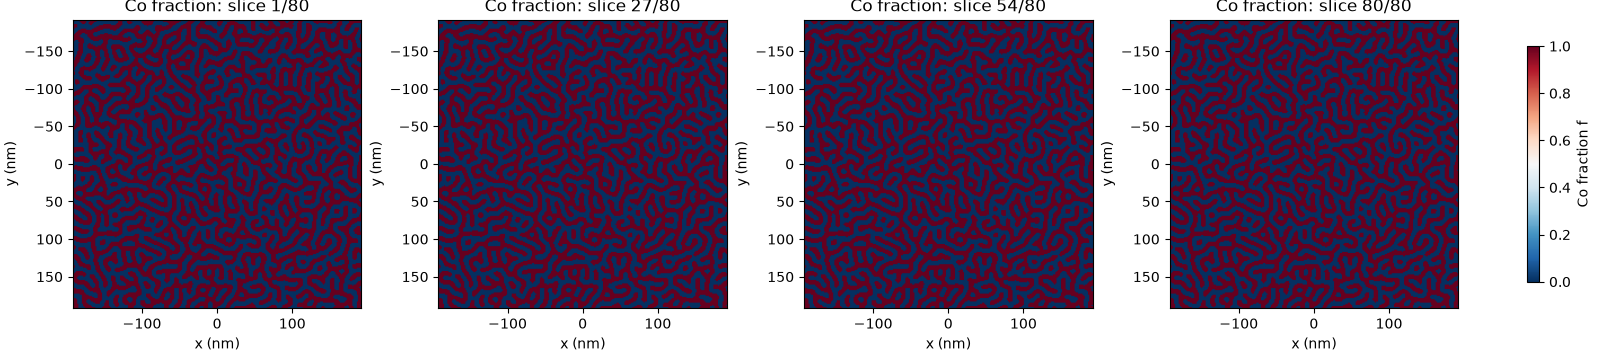

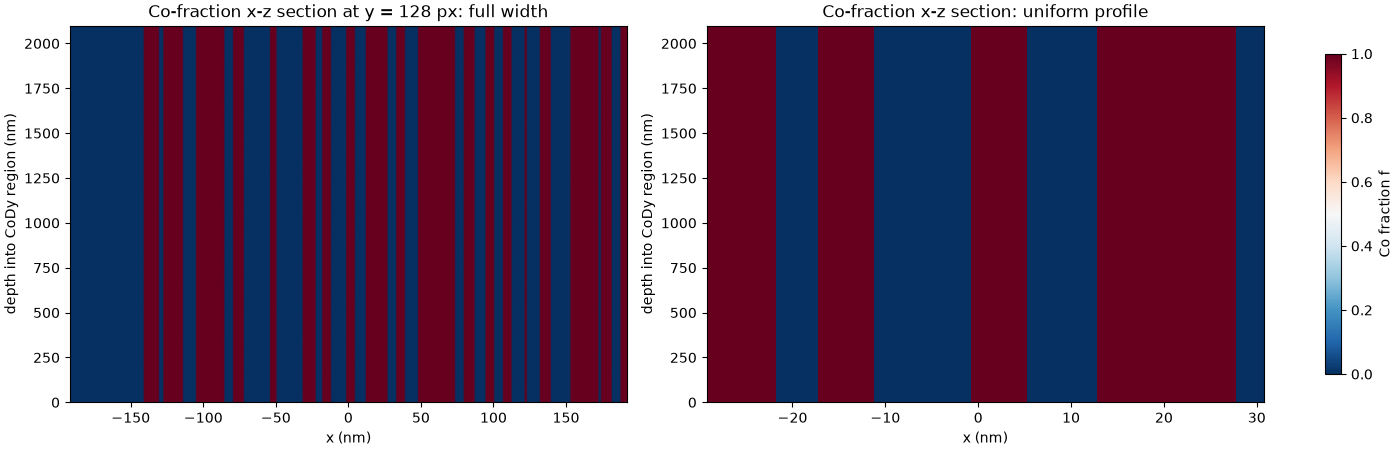

In [54]:
extent_nm = np.array([-grid_shape[1]/2, grid_shape[1]/2, grid_shape[0]/2, -grid_shape[0]/2]) * real_space_pixel_size * 1e9
show_layers = sorted(set([0, N_SUB // 3, 2 * N_SUB // 3, N_SUB - 1]))
fig, axes = plt.subplots(1, len(show_layers), figsize=(4 * len(show_layers), 3.5))
for ax, z in zip(np.atleast_1d(axes), show_layers):
    im = ax.imshow(f_stack[z], cmap="RdBu_r", vmin=0, vmax=1, extent=extent_nm)
    ax.set_title(f"Co fraction: slice {z + 1}/{N_SUB}")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
fig.colorbar(im, ax=np.atleast_1d(axes), label="Co fraction f", shrink=0.8)

# x-z section through the centre row: full width plus a zoom where the
# depth-dependent widening of the chemical columns is easy to see.
section_y = grid_shape[0] // 2
co_fraction_xz = f_stack[:, section_y, :]
zoom_width_px = min(grid_shape[1], max(16, int(round(10 * stripe_width_px))))
zoom_x0 = max(0, grid_shape[1] // 2 - zoom_width_px // 2)
zoom_x1 = min(grid_shape[1], zoom_x0 + zoom_width_px)
zoom_x0 = zoom_x1 - zoom_width_px

full_x_extent_nm = grid_shape[1] * real_space_pixel_size * 1e9 / 2
zoom_x_nm = (np.array([zoom_x0, zoom_x1]) - (grid_shape[1] - 1) / 2) * real_space_pixel_size * 1e9
xz_full_extent = [-full_x_extent_nm, full_x_extent_nm, 0, CODY_TOTAL_NM]
xz_zoom_extent = [zoom_x_nm[0], zoom_x_nm[1], 0, CODY_TOTAL_NM]

fig_xz, axes_xz = plt.subplots(1, 2, figsize=(14, 4.5))
im_full = axes_xz[0].imshow(
    co_fraction_xz, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto",
    origin="lower", extent=xz_full_extent,
)
im_zoom = axes_xz[1].imshow(
    co_fraction_xz[:, zoom_x0:zoom_x1], cmap="RdBu_r", vmin=0, vmax=1,
    aspect="auto", origin="lower", extent=xz_zoom_extent,
)
axes_xz[0].set_title(f"Co-fraction x-z section at y = {section_y} px: full width")
axes_xz[1].set_title(f"Co-fraction x-z section: {chemical_depth_profile} profile")
for ax in axes_xz:
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("depth into CoDy region (nm)")
fig_xz.colorbar(im_zoom, ax=axes_xz, label="Co fraction f", shrink=0.85)

## 4. Build the illumination on the sample grid

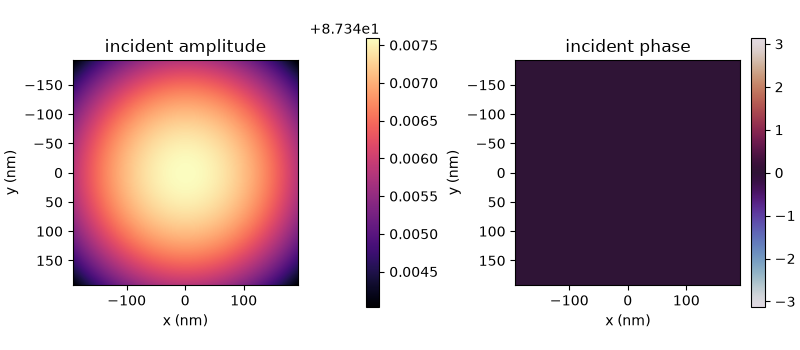

In [55]:
illumination = sim.IlluminationConfig(
    XRayConfig=xray, shape=grid_shape, real_space_pixel_size=real_space_pixel_size,
    illumination_function=illumination_function,
    illumination_config={
        "center": illumination_center, "distance": illumination_focus_distance,
        "fwhm": illumination_fwhm, "alpha_beam": illumination_alpha_beam,
    },
)
illumination.setup()
illumination.update_polarization(polarization)
incident_scalar = illumination.illumination.illumination.copy()

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
im0 = axes[0].imshow(np.abs(incident_scalar), cmap="magma", extent=extent_nm)
im1 = axes[1].imshow(np.angle(incident_scalar), cmap="twilight", vmin=-np.pi, vmax=np.pi, extent=extent_nm)
axes[0].set_title("incident amplitude"); axes[1].set_title("incident phase")
for ax in axes: ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
fig.colorbar(im0, ax=axes[0], shrink=0.8); fig.colorbar(im1, ax=axes[1], shrink=0.8)

## 5. Build the dielectric stack

This is the same composition injection used in Tutorial 14.4, now applied to a mask-free sample. `compact=False` provides one dense dielectric-tensor image per physical slice for the layer-by-layer loop.

In [56]:
mp = material_params(materials={"Co", "Dy"}, x_ray_energy=xray.energy)
n_co = np.asarray(mp.get_refractive_index("Co"), dtype=complex)
n_dy = np.asarray(mp.get_refractive_index("Dy"), dtype=complex)

def inject_chemical_composition(sample, chem_indices, f_stack, n_co, n_dy):
    """Replace each Co slice's isotropic term by its local Co/Dy mixture."""
    if sample.sample_structure.mask is None:
        # A mask-free sample means material everywhere, not a missing mask array.
        support_shape = (len(sample.sample_structure.layer_names), *f_stack.shape[1:])
        sample.assign_aperture_mask(np.ones(support_shape, dtype=float))
    sample.sample_structure.calculate_final_dielectric_tensor(
        use_aperture_roi=False, compact=False
    )
    eps = sample.sample_structure.final_dielectric_tensor
    mask = sample.sample_structure.mask
    m = sample.sample_structure.magnetization
    dt = np.asarray(sample.sample_structure.dielectric_tensors)

    for rel, iz in enumerate(chem_indices):
        n0_local = f_stack[rel] * n_co[0] + (1.0 - f_stack[rel]) * n_dy[0]
        eps0_local = n0_local ** 2
        eps_mz, eps_xy = dt[iz, 1], dt[iz, 2]
        mz_local = m[iz, ..., 2]
        mx_local, my_local = m[iz, ..., 0], m[iz, ..., 1]

        eps_local = np.zeros((*grid_shape, 2, 2), dtype=eps.dtype)
        eps_local[..., 0, 0] = eps0_local
        eps_local[..., 1, 1] = eps0_local
        eps_local += mz_local[..., None, None] * eps_mz[None, None, :, :]
        eps_local += (np.abs(mx_local)**2 - np.abs(my_local)**2)[..., None, None] * eps_xy[None, None, :, :]
        mask_iz = mask[iz][..., None, None]
        eps[iz] = mask_iz * eps_local + (1.0 - mask_iz) * np.eye(2, dtype=eps.dtype)
    return eps

eps_stack = inject_chemical_composition(sample, chem_indices, f_stack, n_co, n_dy)
print("dielectric tensor stack:", eps_stack.shape)

dielectric tensor stack: (84, 256, 256, 2, 2)


## 6. Propagate the illumination through the sample slice by slice

The standard `SamplePropagatorConfig` performs the Jones multislice calculation, including angular-spectrum free-space propagation between slices. Its optional `store_intermediate_wavefields` toggle retains the field after every layer; this is disabled by default in normal simulations to avoid the additional memory cost. `calculate_farfield=False` stops at the final sample surface without performing the Fraunhofer FFT used to propagate to a detector.

In [57]:
propagation = sim.SamplePropagatorConfig(
    SampleConfig=sample, IlluminationConfig=illumination,
    propagator_method="Jones",
    propagator_config={
        "propagate": True,
        "store_intermediate_wavefields": True,
        "calculate_farfield": False,
        "dielectric_tensor_use_roi": False,
    },
)
propagation.setup()
layer_jones_wavefields = propagation.return_intermediate_wavefields()

# Convert the full Jones fields to the co-polarized scalar exit wave used below.
polarization_vector = light_beam.polarization_vector(polarization)
exit_waves = np.einsum(
    "z...s,s->z...", layer_jones_wavefields, np.conjugate(polarization_vector)
)
depth_nm = np.cumsum(layer_thicknesses) * 1e9
print(f"stored {len(exit_waves)} exit waves: {exit_waves.shape}")
for iz, (name, depth) in enumerate(zip(layer_names, depth_nm)):
    print(f"{iz:2d}: after {name:>3s}, cumulative depth = {depth:7.2f} nm")

stored 84 exit waves: (84, 256, 256)
 0: after  Ta, cumulative depth =    4.00 nm
 1: after  Pt, cumulative depth =   10.00 nm
 2: after  Co, cumulative depth =   36.25 nm
 3: after  Co, cumulative depth =   62.50 nm
 4: after  Co, cumulative depth =   88.75 nm
 5: after  Co, cumulative depth =  115.00 nm
 6: after  Co, cumulative depth =  141.25 nm
 7: after  Co, cumulative depth =  167.50 nm
 8: after  Co, cumulative depth =  193.75 nm
 9: after  Co, cumulative depth =  220.00 nm
10: after  Co, cumulative depth =  246.25 nm
11: after  Co, cumulative depth =  272.50 nm
12: after  Co, cumulative depth =  298.75 nm
13: after  Co, cumulative depth =  325.00 nm
14: after  Co, cumulative depth =  351.25 nm
15: after  Co, cumulative depth =  377.50 nm
16: after  Co, cumulative depth =  403.75 nm
17: after  Co, cumulative depth =  430.00 nm
18: after  Co, cumulative depth =  456.25 nm
19: after  Co, cumulative depth =  482.50 nm
20: after  Co, cumulative depth =  508.75 nm
21: after  Co, cum

## 7. Watch the exit wave evolve with thickness

Choose layer indices below, or use the default evenly spaced checkpoints. All amplitude panels share one scale and all phase panels use `[-π, π]`, making thickness changes directly comparable.

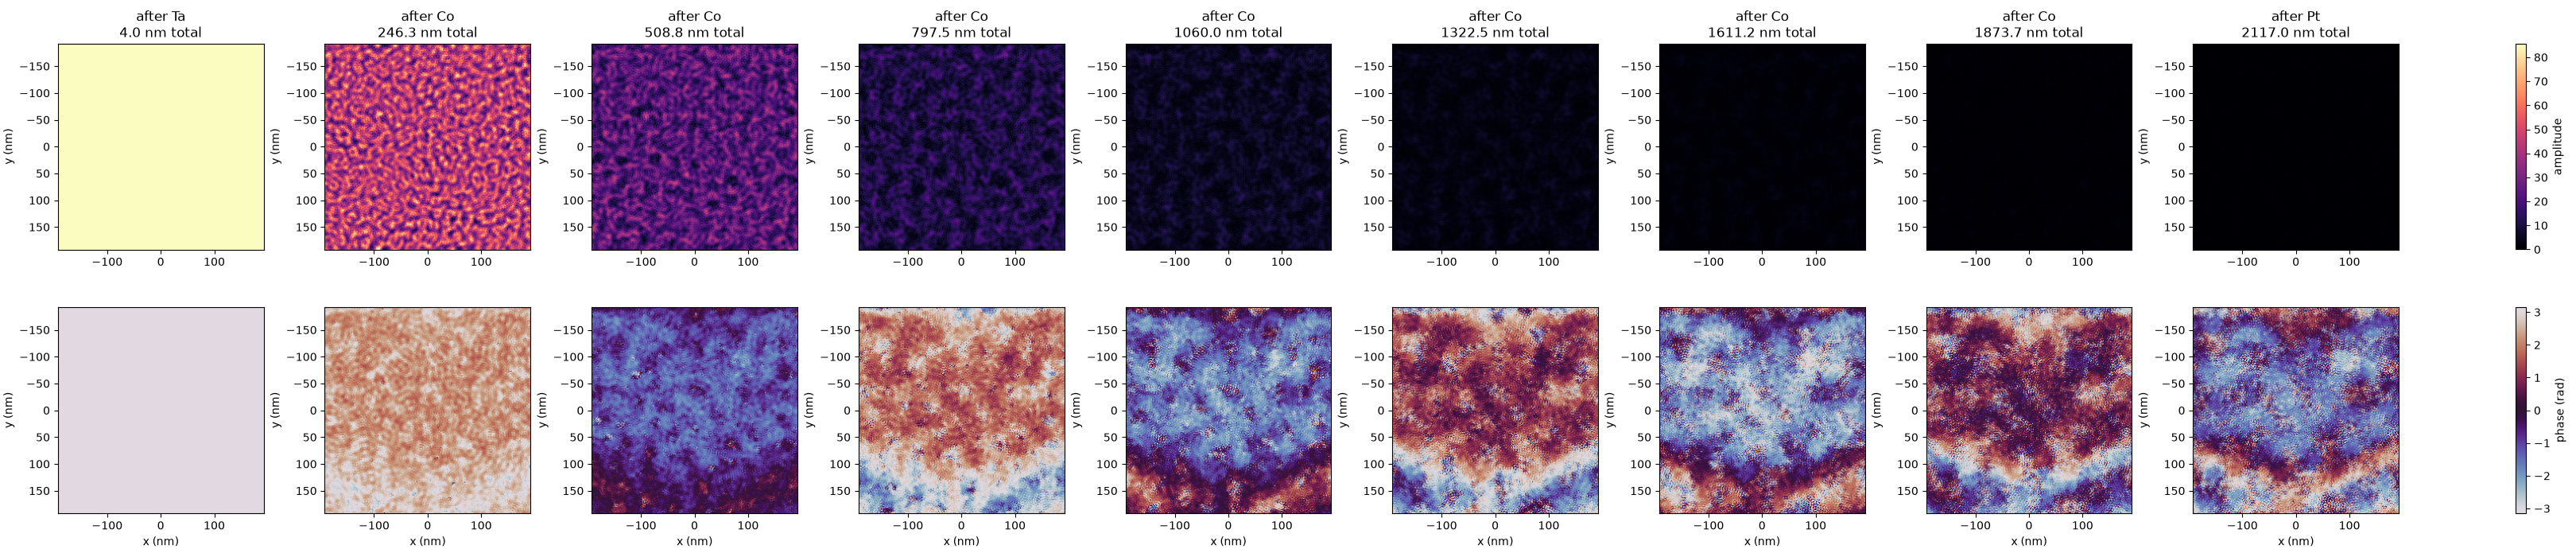

In [58]:
# Replace with explicit indices, e.g. [0, 5, 10, len(layer_names)-1], if desired.
layers_to_show = np.unique(np.linspace(0, len(layer_names) - 1, 9, dtype=int))
amplitude_max = max(np.percentile(np.abs(exit_waves[i]), 99.5) for i in layers_to_show)

fig, axes = plt.subplots(2, len(layers_to_show), figsize=(3.6 * len(layers_to_show), 7))
for col, iz in enumerate(layers_to_show):
    wave = exit_waves[iz]
    amp = axes[0, col].imshow(np.abs(wave), cmap="magma", vmin=0, vmax=amplitude_max, extent=extent_nm)
    phase = axes[1, col].imshow(np.angle(wave), cmap="twilight", vmin=-np.pi, vmax=np.pi, extent=extent_nm)
    title = f"after {layer_names[iz]}\n{depth_nm[iz]:.1f} nm total"
    axes[0, col].set_title(title)
    axes[0, col].set_ylabel("y (nm)"); axes[1, col].set_ylabel("y (nm)")
    axes[1, col].set_xlabel("x (nm)")
fig.colorbar(amp, ax=axes[0, :], label="amplitude", shrink=0.8)
fig.colorbar(phase, ax=axes[1, :], label="phase (rad)", shrink=0.8)

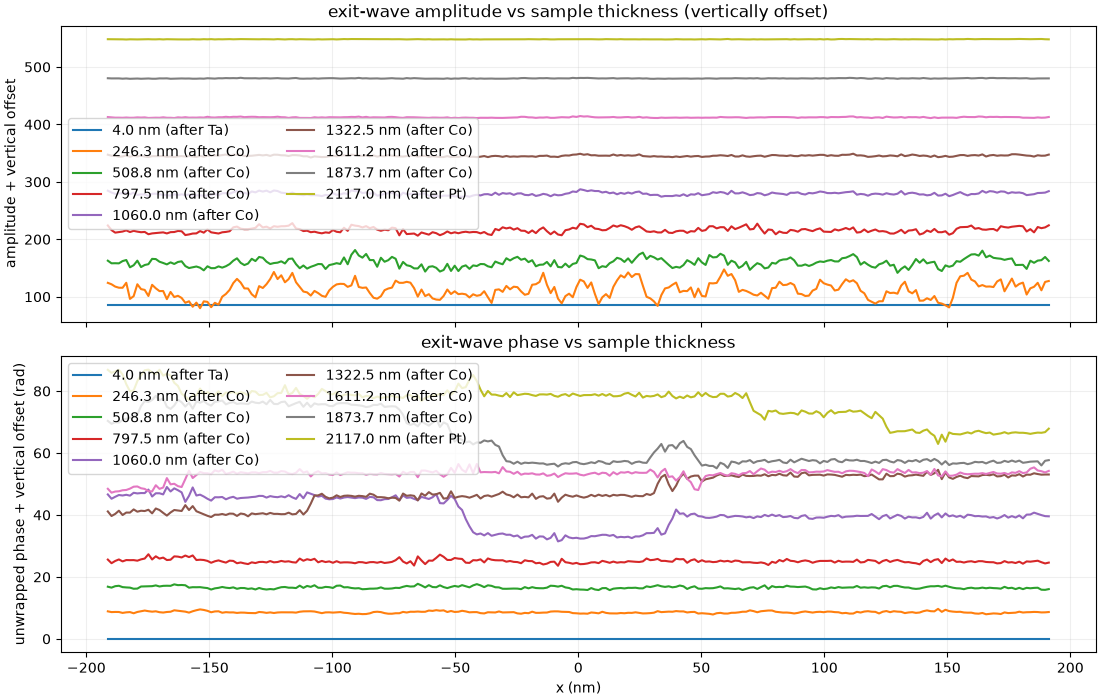

In [60]:
# A horizontal line scan makes small thickness-dependent changes easier to compare.
# Data-driven vertical offsets keep successive layer curves visibly separated.
y_line = grid_shape[0] // 2
x_nm = (np.arange(grid_shape[1]) - (grid_shape[1] - 1) / 2) * real_space_pixel_size * 1e9
amplitude_traces = np.asarray([np.abs(exit_waves[iz, y_line]) for iz in layers_to_show])
phase_traces = np.asarray([np.unwrap(np.angle(exit_waves[iz, y_line])) for iz in layers_to_show])
amplitude_offset = 0.8 * max(np.ptp(amplitude_traces), np.finfo(float).eps)
phase_offset = 0.2 * max(np.ptp(phase_traces-np.amin(phase_traces,axis=0)), np.finfo(float).eps)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for curve_index, iz in enumerate(layers_to_show):
    label = f"{depth_nm[iz]:.1f} nm (after {layer_names[iz]})"
    axes[0].plot(
        x_nm, amplitude_traces[curve_index] + curve_index * amplitude_offset, label=label
    )
    axes[1].plot(
        x_nm, phase_traces[curve_index]-np.amin(phase_traces[curve_index]) + curve_index * phase_offset, label=label
    )
axes[0].set_ylabel("amplitude + vertical offset")
axes[0].set_title("exit-wave amplitude vs sample thickness (vertically offset)")
axes[1].set_ylabel("unwrapped phase + vertical offset (rad)")
axes[1].set_xlabel("x (nm)")
axes[1].set_title("exit-wave phase vs sample thickness")
for ax in axes: ax.legend(ncols=2); ax.grid(alpha=0.2)

## Interpretation

- Moving from left to right adds physical sample layers and includes the angular-spectrum propagation between consecutive slices.
- There is no final Fraunhofer FFT or propagation from the sample exit plane to a detector.
- Amplitude changes show absorption and polarization conversion, while phase changes show the accumulated optical path.
- The Ta/Pt layers mainly contribute spatially uniform attenuation and phase. Spatial structure develops in the CoDy region from its chemical and magnetic textures.
- Increase `N_SUB` to sample the thickness evolution more finely. This does not change the total CoDy thickness.
- Change `polarization`, illumination parameters, film recipe, chemical controls, or magnetic controls at the top and rerun from there.